**Water Stress**

In [1]:
import geopandas as gpd
import pandas as pd
import pyogrio
import numpy as np
import os

# inport files
nhd_gdb_path = "NHDPLUS_H_0207_HU4_20220324_GDB/NHDPLUS_H_0207_HU4_20220324_GDB.gdb"
locations_csv = "water_withdrawal_va/VA_USWWD_Water_Withdrawal_Use_Locations.csv"
data_csv = "water_withdrawal_va/VA_USWWD_Water_Use_Characteristics.csv"
nova_boundary_file = "nova_boundaries.geojson"
output_file = "nova_water_stress_clipped.geojson"

# load data
try:
    df_locs = pd.read_csv(locations_csv)
    df_locs = df_locs[['Water_User_ID', 'Latitude_POU', 'Longitude_POU']].drop_duplicates()
    df_locs = df_locs.rename(columns={'Latitude_POU': 'latitude', 'Longitude_POU': 'longitude'})
    df_data = pd.read_csv(data_csv)
    target_col = "Annual_Volume_Million_Gallons"

    if target_col not in df_data.columns:
        raise ValueError(f"Could not find '{target_col}' in {data_csv}")
    df_data[target_col] = df_data[target_col].fillna(0)
    df_data['daily_mgd'] = df_data[target_col] / 365.0  # converting annual total to daily average

    if 'Latitude_POU' in df_data.columns:    # merging withdrawal data
        df_data = df_data.drop(columns=['Latitude_POU', 'Longitude_POU'])

    df_merged = pd.merge(df_data, df_locs, on='Water_User_ID', how='inner')

    # summing withdrawals
    df_total = df_merged.groupby(['Water_User_ID', 'latitude', 'longitude'])['daily_mgd'].sum().reset_index()
    df_total.rename(columns={'daily_mgd': 'withdrawal_mgd'}, inplace=True)

    # create geodataframe
    gdf_demand = gpd.GeoDataFrame(
        df_total,
        geometry=gpd.points_from_xy(df_total['longitude'], df_total['latitude']),
        crs="EPSG:4326"
    )

except Exception as e:
    print(f" error loading withdrawals: {e}")
    raise

# load supply (NHDPlus)
gdf_catchments = pyogrio.read_dataframe(nhd_gdb_path, layer="NHDPlusCatchment")

if 'nhdplusid' in gdf_catchments.columns:
    gdf_catchments = gdf_catchments.rename(columns={'nhdplusid': 'NHDPlusID'})
elif 'NHDPLUSID' in gdf_catchments.columns:
    gdf_catchments = gdf_catchments.rename(columns={'NHDPLUSID': 'NHDPlusID'})
gdf_catchments = gdf_catchments[['NHDPlusID', 'geometry']]

# flow data
try:
    df_erom = pyogrio.read_dataframe(nhd_gdb_path, layer="NHDPlusEROMMA")
except:
    import fiona
    print(f"   Available layers: {fiona.listlayers(nhd_gdb_path)}")
    raise ValueError("Could not find NHDPlusEROMMA layer.")

if 'nhdplusid' in df_erom.columns:
    df_erom = df_erom.rename(columns={'nhdplusid': 'NHDPlusID'})

# finding flow (QAMA = Mean Annual Flow)
flow_col = next((c for c in df_erom.columns if c.lower() in ['qama', 'qbma', 'qa_ma']), None)
if not flow_col:
    raise ValueError("Could not find QAMA/QBMA flow column in EROM table.")

# converting cfs -> MGD
df_erom = df_erom[['NHDPlusID', flow_col]].copy()
df_erom['supply_mgd'] = df_erom[flow_col] * 0.646317

# calculating water stress
gdf_demand = gdf_demand.to_crs(gdf_catchments.crs)
joined_gdf = gpd.sjoin(gdf_demand, gdf_catchments, how="left", predicate="within")
demand_per_catchment = joined_gdf.groupby('NHDPlusID')['withdrawal_mgd'].sum().reset_index()
demand_per_catchment.rename(columns={'withdrawal_mgd': 'demand_mgd'}, inplace=True)

# merge supply and demand
final_df = pd.merge(gdf_catchments, df_erom, on='NHDPlusID', how='left')
final_df = pd.merge(final_df, demand_per_catchment, on='NHDPlusID', how='left')

# no withdrawal means no demand
final_df['demand_mgd'] = final_df['demand_mgd'].fillna(0)
final_df['supply_mgd'] = final_df['supply_mgd'].fillna(0)

# demand/supply
final_df['water_stress_raw'] = np.where(
    final_df['supply_mgd'] > 0,
    final_df['demand_mgd'] / final_df['supply_mgd'],
    0.0
)

# normalize
final_df['water_stress_norm'] = final_df['water_stress_raw'].clip(upper=1.0)

# clip to nova boundaries and export
if os.path.exists(nova_boundary_file):
    gdf_bounds = gpd.read_file(nova_boundary_file)

    # match CRS
    if gdf_bounds.crs != final_df.crs:
        gdf_bounds = gdf_bounds.to_crs(final_df.crs)

    nova_clipped = gpd.clip(final_df, gdf_bounds)

    # save clipped file
    nova_clipped.to_file(output_file, driver='GeoJSON')
else:
    print(f" warning: boundary file '{nova_boundary_file}' not found.")
    print("   Saving full basin map instead.")
    final_df.to_file("nova_water_stress_FULL.geojson", driver='GeoJSON')

⏳ Loading Withdrawal Data...
   ✅ Processed 6144 withdrawal points.
⏳ Loading NHDPlus Supply...
📍 Calculating Water Stress...
✂️ Clipping to Northern Virginia...
🎉 Success! Saved clipped layer to: nova_water_stress_clipped.geojson


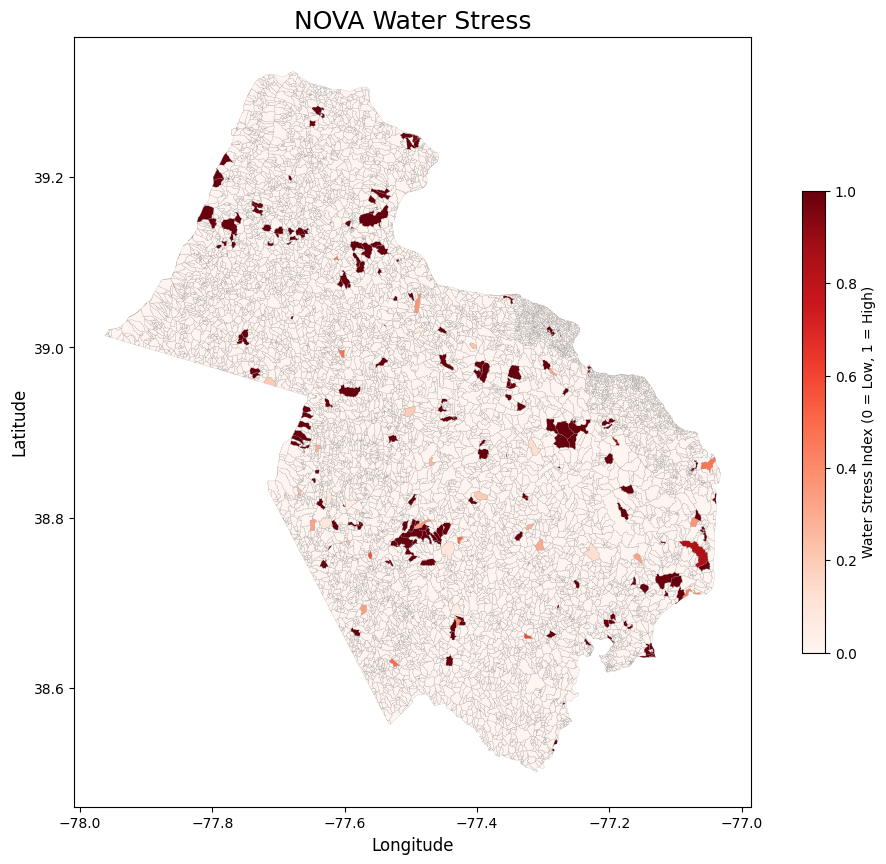

In [11]:
import geopandas as gpd
import matplotlib.pyplot as plt

file_path = "nova_water_stress_clipped.geojson"
gdf = gpd.read_file(file_path)

fig, ax = plt.subplots(figsize=(13, 10))

gdf.plot(
    column='water_stress_norm',
    cmap='Reds',
    linewidth=0.1,
    edgecolor='grey',
    legend=True,
    legend_kwds={
        'label': "Water Stress Index (0 = Low, 1 = High)",
        'shrink': 0.6
    },
    ax=ax
)

ax.set_title("NOVA Water Stress", fontsize=18)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)
plt.savefig("nova_water_stress_map.png", dpi=300, bbox_inches='tight')
plt.show()

In [3]:
print(gdf[['supply_mgd', 'demand_mgd', 'water_stress_norm']].describe())

         supply_mgd    demand_mgd  water_stress_norm
count  13806.000000  13806.000000       13806.000000
mean      86.950905      1.477432           0.016317
std      869.229128     79.947196           0.124235
min        0.000000      0.000000           0.000000
25%        0.062616      0.000000           0.000000
50%        0.187544      0.000000           0.000000
75%        0.775585      0.000000           0.000000
max    10950.672363   7314.366778           1.000000


In [13]:
# distribution of data
stress_col = gdf['water_stress_norm']
zeros = len(gdf[stress_col == 0])
ones = len(gdf[stress_col == 1.0])
middle = len(gdf[(stress_col > 0) & (stress_col < 1.0)])

print(f" total catchments: {len(gdf)}")
print(f" unstressed (0.0): {zeros}  ({zeros/len(gdf)*100:.1f}%)")
print(f" fully stressed (1.0): {ones}   ({ones/len(gdf)*100:.1f}%)")
print(f" partially stressed (0.0 - 1.0): {middle}  ({middle/len(gdf)*100:.1f}%)")

 total catchments: 13806
 unstressed (0.0): 13520  (97.9%)
 fully stressed (1.0): 207   (1.5%)
 partially stressed (0.0 - 1.0): 79  (0.6%)
